In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # 0=all messages, 1=information, 2=warning, 3=error
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow_probability as tfp
import time
from dolfin import *

I0000 00:00:1788160605.943773    8228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788160605.944171    8228 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788160607.026754    8228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788160607.026999    8228 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
t1 = time.time()
# Float precision
tf.keras.backend.set_floatx('float64')
number_type = tf.float64

# x -> matrix where each column is a dimension
# Exact solution and RHS
def u_exact(x):
    return np.sin(np.pi * x[:, 0:1]) * np.sin(np.pi * x[:, 1:2]) # in this way we keep u_exact with the same structure as x

def f(x):
    return 2.0 * PI_SQR * tf.sin(PI * x[:, 0:1]) * tf.sin(PI * x[:, 1:2])

# Neural network model
# The class PINN inherits from the clss tf.keras.Model that is used to define neural networks
# Remember that the input of a tensorflow NN is a tensor of shape [batch_size, features], therefore if we pass a tensor of points
# in R it should be a tensor of shape [N_points, 1]. The features shape is enforced when needed in this code

# PINN CLASS 
class PINN(tf.keras.Model):
    # PINN constructor
    def __init__(self, n_neurons):
        # Initialize the PINN with the initializer of the parent class
        super().__init__()
        # Define the member variable for the hidden layers and the output layer
        # The dimension of the input is automatically determined by the first input passed to the PINN
        # Remark. You can pass additional arguments to the __init__ constructor to define a custom architecture:
        # activation functions per hidden layer, weights regularization, etc.
        self.hidden = [tf.keras.layers.Dense(l, activation='tanh') for l in n_neurons]
        # Automatically sets a linear activation function h(x) = ax+b and outputs the approximation of u(x)
        # (u is a scalar function with one component)
        self.out = tf.keras.layers.Dense(1)

    # Apply the PINN to the input x by passing through each layer
    def call(self, x):
        z = x
        for layer in self.hidden:
            z = layer(z)
        return self.out(z)

# Training step function with the @tf.function decorator for speed up
# jit_compile=True: more speed up
@tf.function(jit_compile=True)
def train_step(model, optimizer, x_int, x_bc):
    # Compute the gradient of the loss function
    with tf.GradientTape() as tape:
        loss, lpde, lbc = loss_fn(model, x_int, x_bc)
    grads = tape.gradient(loss, model.trainable_variables)
    # Apply the optimizer
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, lpde, lbc

# Compute PDE residual
def compute_residual(model, x):
    # We use GradientTape to compute the derivative (and use tape1 and tape2 as variable name for the GradientTape)
    # A possible argument of the GradientTape constructor is the persistent boolean. This is by default false, meaning that you
    # can call the gradient() method only once per tape. Therefore you can only compute one set of derivatives.
    
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    with tf.GradientTape(persistent=True) as tape2:
        # Use tape2 to derive with respect to x (2 suggests that it is used for the second derivative)
        # tape2 will register all the operations in x to compute the derivative by means of automatic differentiation,
        # thus computing the right expression of u''(x) (NOT u_exact but its approximation)
        tape2.watch(x1)
        tape2.watch(x2)
        with tf.GradientTape(persistent=True) as tape1:
            # Use tape1 to derive with respect to x (1 suggests that it is used for the first derivative)
            tape1.watch(x1)
            tape1.watch(x2)

            # recompose x to pass it as model input
            x_input = tf.concat([x1, x2], axis=1)
            # Compute u(x)
            u = model(x_input)
        # compute derivatives wrt x and y
        u_x = tape1.gradient(u, x1)
        u_y = tape1.gradient(u, x2)
    u_xx = tape2.gradient(u_x, x1)
    u_yy = tape2.gradient(u_y, x2)

    # delete tapes to free memory
    del tape1
    del tape2
    laplacian = u_xx + u_yy
    # If the residual is 0, you would solve the PDE (the BCs are considered later)
    return -laplacian - f(x_input)

# Loss function
def loss_fn(model, x_interior, x_boundary):
    # PDE residual loss
    res = compute_residual(model, x_interior)
    # Mean squared error
    loss_pde = tf.reduce_mean(tf.square(res))

    # Boundary loss
    u_bc = model(x_boundary)
    # Homogeneous Dirichlet BCs
    loss_bc = tf.reduce_mean(tf.square(u_bc))

    total_loss = loss_pde + loss_bc
    return total_loss, loss_pde, loss_bc

# points have to be generated in a square 
def generate_interior_grid(N, random = False):
    if random:
        return tf.convert_to_tensor(np.random.rand(N, 2), dtype = number_type)
    else:
        # Avoid boundary nodes
        N_dim = int(np.sqrt(N))
        x_lin = np.linspace(0.05, 0.95, N_dim)
        y_lin = np.linspace(0.05, 0.95, N_dim)
        X_grid, Y_grid = np.meshgrid(x_lin, y_lin)
        # grid into a matrix with dim [N, 2]
        points = np.hstack((X_grid.flatten()[:, None], Y_grid.flatten()[:, None]))
        return tf.convert_to_tensor(points, dtype=number_type)
    
def generate_boundary_grid(N_per_edge=100):
    s = np.random.rand(N_per_edge, 1)
    zeros = np.zeros_like(s)
    ones = np.ones_like(s)

    bottom = np.hstack((s, zeros))     # y = 0
    top = np.hstack((s, ones))         # y = 1
    left = np.hstack((zeros, s))       # x = 0
    right = np.hstack((ones, s))       # x = 1
    bc_points = np.vstack((bottom, top, left, right))
    return tf.convert_to_tensor(bc_points, dtype = number_type)

# Function that L-BFGS uses to compute loss and gradients w.r.t. PINN weights
def function_factory(model, loss_fn, x_int, x_bc):
    def loss_grad(weights):
        # Update model weights with those obtained using L-BFGS
        set_model_weights(model, weights)

        with tf.GradientTape() as tape:
            loss, _, _ = loss_fn(model, x_int, x_bc)

        grads = tape.gradient(loss, model.trainable_variables)
        # Convert the gradients into a flat vector that L-BFGS can use
        grads_flat = tf.concat([tf.reshape(g, [-1]) for g in grads], axis=0)

        return loss, grads_flat

    return loss_grad

# Support function to set model weights from a flat vector
def set_model_weights(model, weights_flat):
    sizes = [v.shape.num_elements() for v in model.trainable_variables]
    tensors = tf.split(weights_flat, sizes)
    for v, t in zip(model.trainable_variables, tensors):
        v.assign(tf.reshape(t, v.shape))

# Fix code reproducibility
np.random.seed(1)
random.seed(1)
tf.random.set_seed(1)

# PDE constants to not implicitly convert from numpy to tensorflow and speed up the code
PI = tf.constant(np.pi, dtype = number_type)
PI_SQR = tf.constant(np.pi**2, dtype = number_type)

# Training
n_neurons = [20, 20, 20]
model = PINN(n_neurons)
# Dummy input  to build all the layers and determine the input layer shape.
# Moreover, this dummy input is used to be sure that the loaded and saved PINNs produce the same results
model(tf.zeros((1, 2))) 
# If you want to load a pre-trained PINN, you need to do:
# model2 = PINN()
# model2(tf.zeros((1, 2)))
# model2.load_weights('pinn_2DLaplacian_weights.weights.h5')
# where pinn_2DLaplacian_weights.weights.h5 is a file containing the weights and biases of the pre-trained PINN

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Collocation points
N_interior = 2000
N_edge = 100 # total of 400 points on the boundary
h_domain = (1.0-0.0)/(N_interior+1)

# Use tf.tensor objects to speed up training
# Take randomly N_interior training points in (0,1) where we want to minimize the residual of the PDE
x_interior_train = generate_interior_grid(N_interior, random=True)
x_interior_test = generate_interior_grid(N_interior, True)

x_boundary_train = generate_boundary_grid(N_edge)
x_boundary_test = generate_boundary_grid(N_edge)

# Train using two optimizers:
# 1) Adam optimizer: a stochastic gradient-based method used to escape local minima
#    and move toward the region of the global minimum.
# 2) L-BFGS optimizer: a quasi-Newton method used to achieve faster convergence
#    to the global minimum once its region has been reached with Adam.
# Training loop
epochs = 1000
print('Starting Adam optimization...')
for epoch in range(epochs+1):
    if epoch == 0:
        loss, lpde, lbc = loss_fn(model, x_interior_train, x_boundary_train)
    if epoch % 500 == 0:
        test_loss, test_lpde, test_lbc = loss_fn(model, x_interior_test, x_boundary_test)
        print(f'Epoch {epoch}')
        print(f'\tLoss     : {loss.numpy():.4e}\tLoss pde     : {lpde.numpy():.4e}\tLoss bc     : {lbc.numpy():.4e}')
        # Check if you are generalizing well
        print(f'\tTest loss: {test_loss.numpy():.4e}\tTest loss pde: {test_lpde.numpy():.4e}\tTest loss bc: {test_lbc.numpy():.4e}')

    loss, lpde, lbc = train_step(model, optimizer, x_interior_train, x_boundary_train)
print('Adam optimization completed!')

print('Starting L-BFGS optimization...')
# Initial weights (from Adam optimization)
init_weights = tf.concat([tf.reshape(v, [-1]) for v in model.trainable_variables], axis=0)
# Optimization
optim_results = tfp.optimizer.lbfgs_minimize(function_factory(model, loss_fn, x_interior_train, x_boundary_train),
                                            initial_position=init_weights,
                                            max_iterations=5000,
                                            num_correction_pairs=20,
                                            tolerance=1e-8)
# Set final weights
set_model_weights(model, optim_results.position)

print('L-BFGS optimization completed!')
# Save the weights of the trained model
model.save_weights('pinn_2DLaplacian_weights.weights.h5')
print('PINN weights saved')

print('L-BFGS converged:', optim_results.converged.numpy())
print('L-BFGS iterations:', optim_results.num_iterations.numpy())
train_loss, train_lpde, train_lbc = loss_fn(model, x_interior_train, x_boundary_train)
test_loss, test_lpde, test_lbc = loss_fn(model, x_interior_test, x_boundary_test)
print(f'\tLoss     : {train_loss.numpy():.4e}\tLoss pde     : {train_lpde.numpy():.4e}\tLoss bc     : {train_lbc.numpy():.4e}')
print(f'\tTest loss: {test_loss.numpy():.4e}\tTest loss pde: {test_lpde.numpy():.4e}\tTest loss bc: {test_lbc.numpy():.4e}')

print(f'Execution time: {time.time()-t1:.4f}')

E0000 00:00:1788160609.675029    8228 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Starting Adam optimization...
Epoch 0
	Loss     : 1.0584e+02	Loss pde     : 1.0560e+02	Loss bc     : 2.3505e-01
	Test loss: 1.0774e+02	Test loss pde: 1.0748e+02	Test loss bc: 2.5758e-01
Epoch 500
	Loss     : 3.9596e-01	Loss pde     : 3.0418e-01	Loss bc     : 9.1774e-02
	Test loss: 4.1267e-01	Test loss pde: 3.1501e-01	Test loss bc: 9.7656e-02
Epoch 1000
	Loss     : 6.5545e-02	Loss pde     : 5.2098e-02	Loss bc     : 1.3447e-02
	Test loss: 6.9179e-02	Test loss pde: 5.5790e-02	Test loss bc: 1.3388e-02
Adam optimization completed!
Starting L-BFGS optimization...
L-BFGS optimization completed!
PINN weights saved
L-BFGS converged: False
L-BFGS iterations: 5000
	Loss     : 2.2835e-06	Loss pde     : 1.8838e-06	Loss bc     : 3.9965e-07
	Test loss: 2.5220e-06	Test loss pde: 2.0993e-06	Test loss bc: 4.2275e-07
Execution time: 895.2503


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.


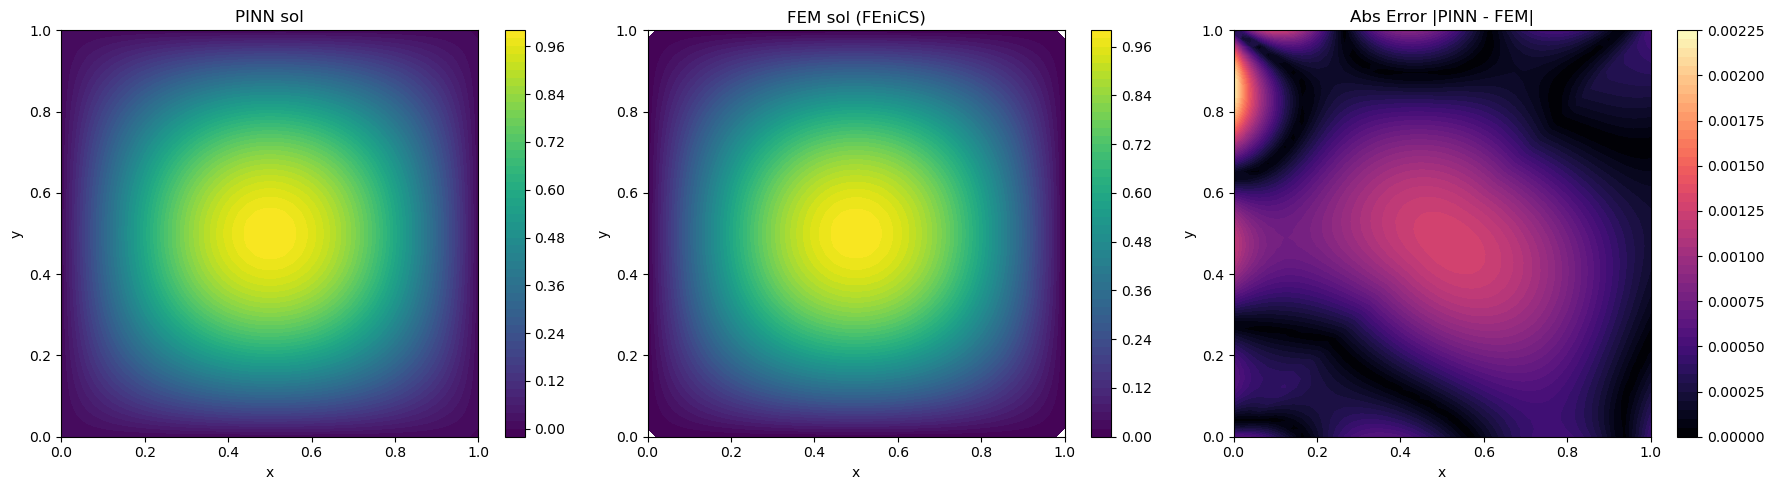

In [3]:
# Evaluation in points different from the training ones
# You are testing the PINN generalization, that is the capability of solving the PDE also outside the training points
N_points = 50 #50x50=2500 test points
x_test = np.linspace(0, 1, N_points)
y_test = np.linspace(0, 1, N_points)
X_test, Y_test = np.meshgrid(x_test, y_test)
# flatten the grid to create matrix
X_test_flat = np.hstack((X_test.flatten()[:, None], Y_test.flatten()[:, None]))
u_pred = model(tf.convert_to_tensor(X_test_flat, dtype = number_type)).numpy()
u_true = u_exact(X_test_flat)

# Using dolfin library we solve the 1D Laplace problem with FEM
# Mesh
mesh = UnitSquareMesh(N_points, N_points)
# FEM with polynomial degree 1
V = FunctionSpace(mesh, 'CG', 1)

# Dirichlet BCs
u_D = Constant(0.0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

# Solution and test functions in FEM space
u = TrialFunction(V)
v = TestFunction(V)
# Use polynomial of degree 2 to approximate f(x)
f = Expression('2.0 * pi * pi * sin(pi*x[0]) * sin(pi*x[1])', degree=4)

# Weak formulation -> same as 1D
a = dot(grad(u), grad(v)) * dx
L = f * v * dx

# Solving
u_sol = Function(V)
solve(a == L, u_sol, bc)

# FEM sol evaluated at same points of the PINN
u_fem_vals = np.array([u_sol(pt) for pt in X_test_flat])


U_pred_2d = u_pred.reshape(N_points, N_points)
U_fem_2d = u_fem_vals.reshape(N_points, N_points)

Error_PINN_FEM = np.abs(U_pred_2d - U_fem_2d)

# PLOTS 
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. PINN SOLUTION
c1 = axs[0].contourf(X_test, Y_test, U_pred_2d, levels=50, cmap='viridis')
axs[0].set_title('PINN sol')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
fig.colorbar(c1, ax=axs[0])

# 2. FEM SOLUTION
c2 = axs[1].contourf(X_test, Y_test, U_fem_2d, levels=50, cmap='viridis')
axs[1].set_title('FEM sol (FEniCS)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
fig.colorbar(c2, ax=axs[1])

# 3. ERROR
c3 = axs[2].contourf(X_test, Y_test, Error_PINN_FEM, levels=50, cmap='magma')
axs[2].set_title('Abs Error |PINN - FEM|')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')
fig.colorbar(c3, ax=axs[2])

plt.tight_layout()
plt.show()